# Step 1 — OpenVLA **Mock** Profiling (dry run)

Validates the logging pipeline **without** downloading OpenVLA-7B. Use this on your Mac to test `import src` and output files.

For **real** latency numbers, use **`step1_openvla_profiling.ipynb`** on a lab GPU machine.

**Equivalent CLI:**
```bash
cd research_summer_2026/research
python -m src.step1_profile_openvla --mock --n_trials 20 \
  --instruction "Pick up the pen on the book on the table and give it to me"
```

In [8]:
from pathlib import Path
import os
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "notebooks":
    RESEARCH_DIR = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "src" / "step1_profile_openvla.py").is_file():
    RESEARCH_DIR = NOTEBOOK_DIR
else:
    RESEARCH_DIR = NOTEBOOK_DIR / "research_summer_2026" / "research"
    if not RESEARCH_DIR.is_dir():
        RESEARCH_DIR = NOTEBOOK_DIR / "research"

RESEARCH_DIR = RESEARCH_DIR.resolve()
assert (RESEARCH_DIR / "src").is_dir(), f"src package not found under: {RESEARCH_DIR}"

os.chdir(RESEARCH_DIR)
if str(RESEARCH_DIR) not in sys.path:
    sys.path.insert(0, str(RESEARCH_DIR))

print(f"Research root : {RESEARCH_DIR}")
print(f"Results go to : {RESEARCH_DIR / 'results'}")

Research root : /Users/andrew/Desktop/competitions/research_summer_2026/research
Results go to : /Users/andrew/Desktop/competitions/research_summer_2026/research/results


In [9]:
# Experiment config (edit here)
MOCK = True
N_TRIALS = 20
INSTRUCTION = "Pick up the pen on the book on the table and give it to me"
MODEL_ID = "openvla/openvla-7b"  # ignored when MOCK=True
USE_INT4 = False

## Run profiling (same as `main()` / CLI)

In [10]:
from src.step1_profile_openvla import (
    MockG1SimEnv,
    OpenVLAWrapper,
    G1_DOF,
    TARGET_HZ,
    RESULTS_DIR,
    profile_openvla,
    save_logs,
    plot_profiling_report,
)

env = MockG1SimEnv(image_size=(224, 224))
model = OpenVLAWrapper(
    model_id=MODEL_ID if not MOCK else "__mock__",
    use_int4=USE_INT4,
    action_dim=G1_DOF,
)

report, records = profile_openvla(
    model=model,
    env=env,
    n_trials=N_TRIALS,
    instruction=INSTRUCTION,
)

save_logs(report, records)
plot_profiling_report(report, records)

print("\n" + "=" * 60)
print("  PROFILING COMPLETE — Week 1-2 Deliverable (mock)")
print("=" * 60)
print(f"  Instruction    : {INSTRUCTION}")
print(f"  Mean latency   : {report.mean_latency_ms:.1f} ± {report.std_latency_ms:.1f} ms")
print(f"  Control rate   : {report.mean_hz:.2f} Hz  (target: {TARGET_HZ} Hz)")
print(f"  Frequency gap  : {report.frequency_gap:.1f}x")
print(f"  Failure rate   : {report.failure_rate * 100:.1f}%")
print(f"  Outputs        : {RESULTS_DIR.resolve()}")
print("=" * 60)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/Users/andrew/Downloads/RESEARCH-01/workshop/ai-deeds/challenge/Smart Buildings/.venv311/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/andrew/Downl


  PROFILING COMPLETE — Week 1-2 Deliverable (mock)
  Instruction    : Pick up the pen on the book on the table and give it to me
  Mean latency   : 398.0 ± 41.2 ms
  Control rate   : 2.51 Hz  (target: 100 Hz)
  Frequency gap  : 39.8x
  Failure rate   : 0.0%
  Outputs        : /Users/andrew/Desktop/competitions/research_summer_2026/research/results/step1_profiling


## Optional: run via subprocess (exact CLI)

In [11]:
# Uncomment to re-run via module CLI instead of imports above.
# import subprocess
# cmd = [
#     sys.executable,
#     "-m", "src.step1_profile_openvla",
#     "--mock",
#     "--n_trials", str(N_TRIALS),
#     "--instruction", INSTRUCTION,
# ]
# subprocess.run(cmd, cwd=RESEARCH_DIR, check=True)

## Inspect results

OpenVLA Profiling Report — Week 1-2 Deliverable
Model: __mock__

Latency (ms):
  Mean   : 397.97 ± 41.19
  Median : 400.99
  P95    : 447.78
  P99    : 470.86

Control Rate:
  Mean   : 2.513 Hz
  Target : 100 Hz
  Gap    : 39.8x below G1 requirement

Failure Analysis:
  Rate   : 0.0%
  Modes  : {}

Motivation for ESN Bridge:
  The 40x frequency gap between OpenVLA's
  2.5 Hz and G1's 100 Hz requirement
  directly motivates the ESN bridge in Objective 02.



{'model_id': '__mock__',
 'n_trials': 20,
 'mean_latency_ms': 397.96708729918464,
 'std_latency_ms': 41.19030137311984,
 'median_latency_ms': 400.9903709993523,
 'p95_latency_ms': 447.77875060244696,
 'p99_latency_ms': 470.8583485244889,
 'mean_hz': 2.5127706082091597,
 'target_hz': 100,
 'frequency_gap': 39.796708729918464,
 'mean_gpu_mem_gb': 0.0,
 'action_dim': 29,
 'action_mean': [-0.001737157255411148,
  -0.042682593362405895,
  0.06092215310782194,
  0.040255303122103216,
  0.023947399567987304,
  0.006548626068979502,
  -0.048014690075069665,
  0.04331625485792756,
  0.03851831750944257,
  -0.03126605749130249,
  -0.012229032861068845,
  0.01852467383723706,
  0.07692701132036746,
  0.11691776849329472,
  0.010977731924504042,
  0.053611303120851515,
  -0.07638481669127942,
  0.009563320269808172,
  -0.040310130221769214,
  0.015584556385874748,
  0.0024770062416791918,
  -0.08691206453368068,
  0.006481930613517761,
  0.025053415354341267,
  -0.043721590749919416,
  -0.01323165

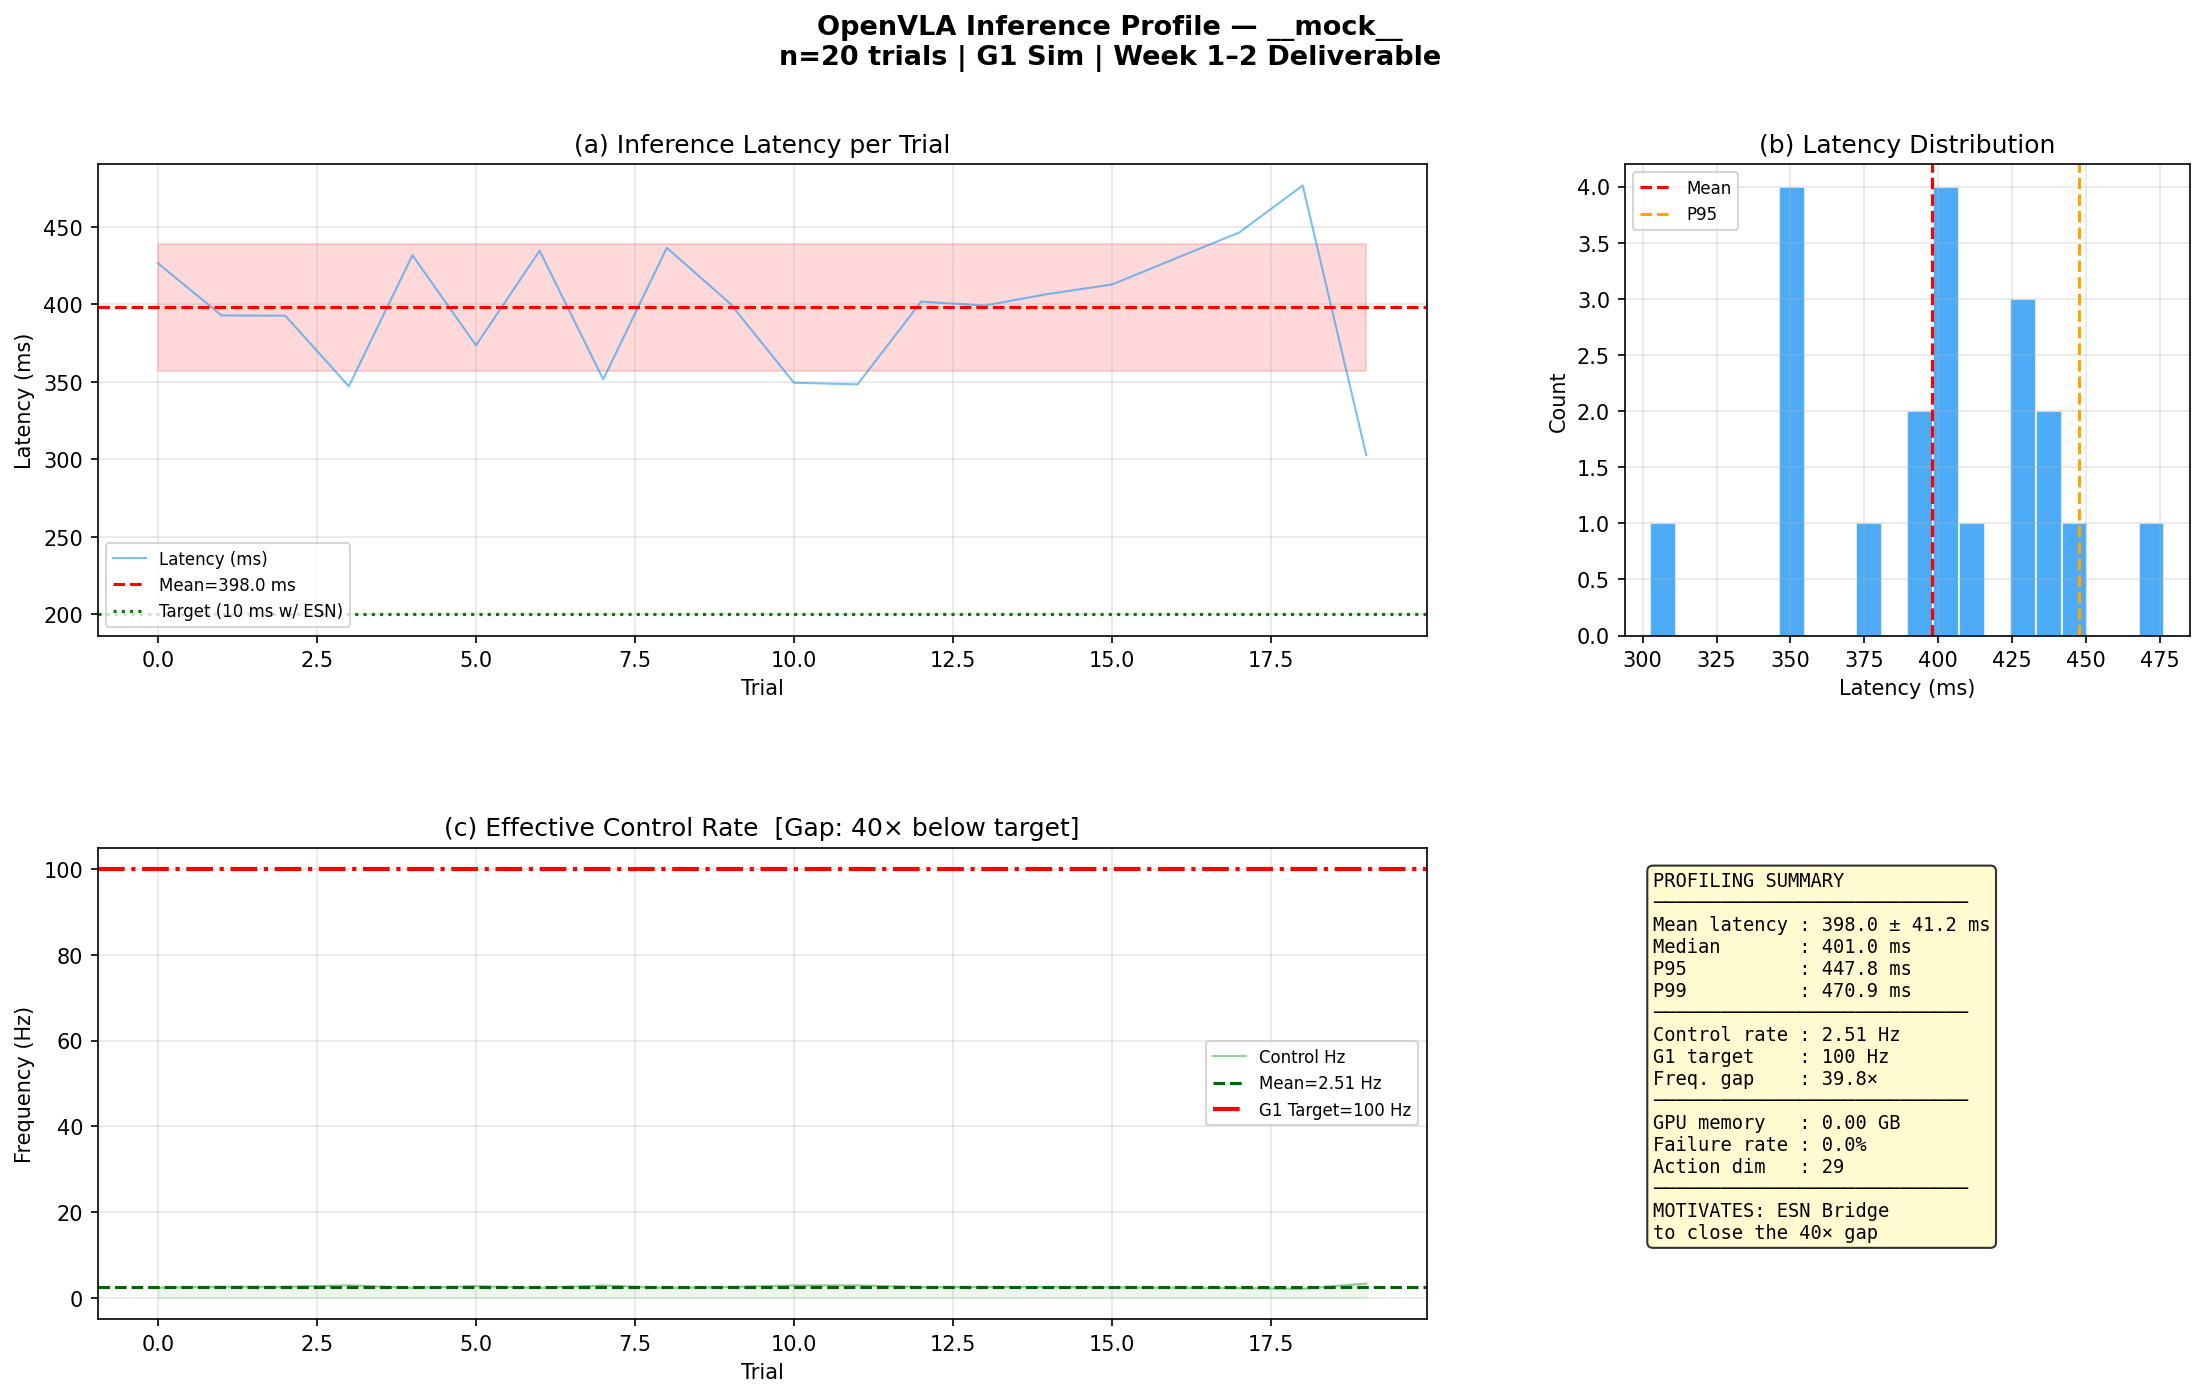

In [12]:
import json
from IPython.display import Image, display

summary_path = RESULTS_DIR / "profiling_summary.txt"
report_path = RESULTS_DIR / "profiling_report.json"
fig_path = RESULTS_DIR / "openvla_profiling_report.png"

if summary_path.exists():
    print(summary_path.read_text())

if report_path.exists():
    display(json.loads(report_path.read_text()))

if fig_path.exists():
    display(Image(filename=str(fig_path)))